In [3]:
import joblib

xgb_weighted = joblib.load(
    "../models/xgb_weighted_model.pkl"
)

<Figure size 1200x800 with 0 Axes>

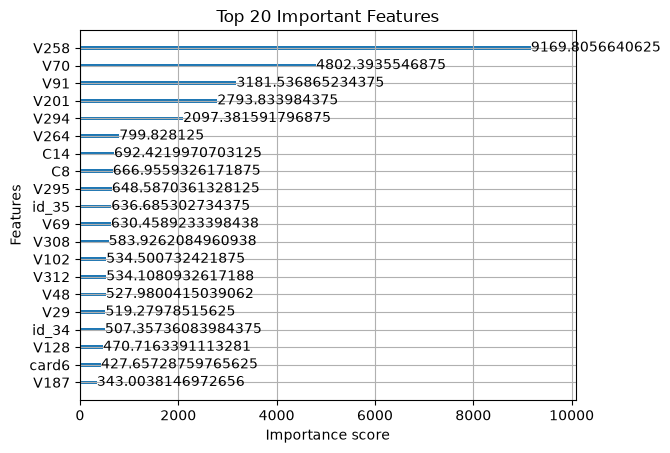

In [4]:
import matplotlib.pyplot as plt
import xgboost as xgb

plt.figure(figsize=(12,8))

xgb.plot_importance(
    xgb_weighted,
    max_num_features=20,
    importance_type="gain"
)

plt.title("Top 20 Important Features")
plt.show()

In [7]:
joblib.dump(xgb_weighted,
            "../models/xgb_weighted_model.pkl")

['../models/xgb_weighted_model.pkl']

In [8]:
joblib.load("../models/xgb_weighted_model.pkl")

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [9]:
import os

os.listdir("../models")

['final_xgb_model.pkl', 'xgb_weighted_model.pkl']

In [10]:
import pandas as pd
import numpy as np

import joblib
import xgboost as xgb
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [11]:
train = pd.read_pickle(
    "../data/train_feature_engineered.pkl"
)

print(train.shape)

(590540, 432)


In [12]:
X = train.drop(
    columns=["isFraud", "TransactionID"]
)

categorical_cols = X.select_dtypes(
    include=["object", "category"]
).columns

from sklearn.preprocessing import LabelEncoder

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(
        X[col].astype(str)
    )

print(X.shape)

(590540, 430)


In [13]:
xgb_weighted = joblib.load(
    "../models/xgb_weighted_model.pkl"
)

print("Model Loaded Successfully")

Model Loaded Successfully


<Figure size 1200x800 with 0 Axes>

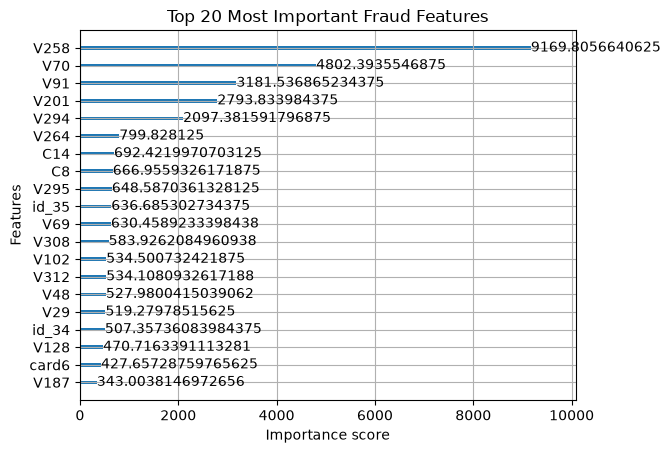

In [ ]:
# Feature Importance
plt.figure(figsize=(12,8))

xgb.plot_importance(
    xgb_weighted,
    max_num_features=20,
    importance_type="gain"
)

plt.title("Top 20 Most Important Fraud Features")

plt.show()

In [15]:
# Get Feature Names Numerically
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_weighted.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

importance_df.head(20)

,Feature,Importance
310,V258,0.145597
122,V70,0.076252
143,V91,0.050516
253,V201,0.044360
346,V294,0.033302
316,V264,0.012700
28,C14,0.010994
22,C8,0.010590
347,V295,0.010298
417,id_35,0.010109


In [16]:
import shap

print(shap.__version__)

0.51.0


In [17]:
import shap

explainer = shap.TreeExplainer(
    xgb_weighted
)

sample_data = X.sample(
    1000,
    random_state=42
)

shap_values = explainer.shap_values(
    sample_data
)

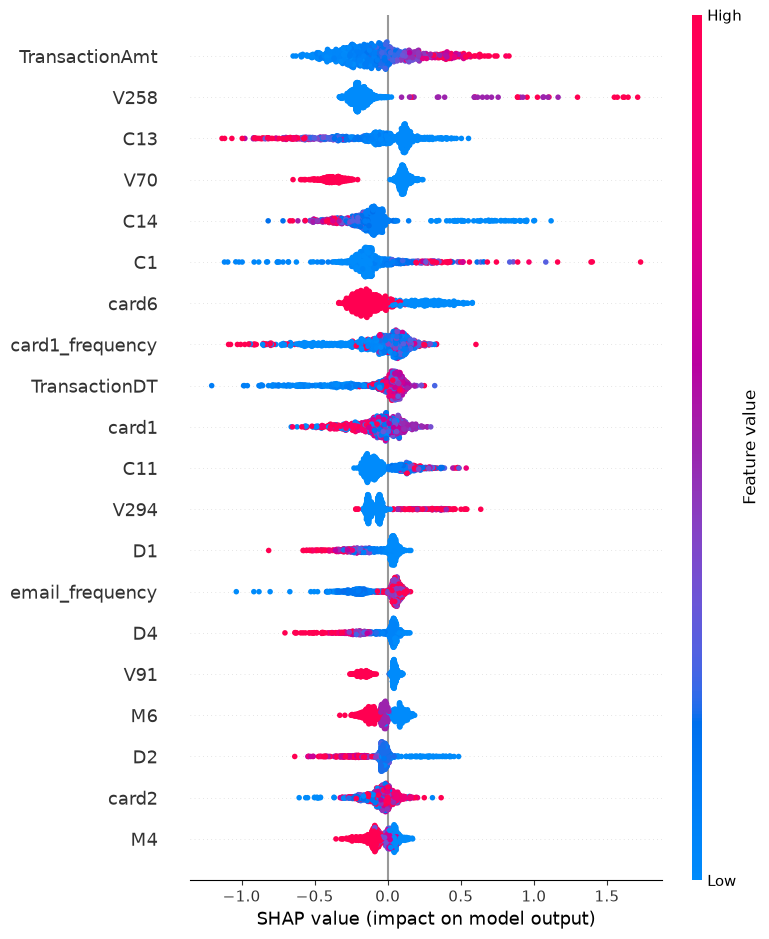

In [18]:
shap.summary_plot(
    shap_values,
    sample_data
)

In [19]:
importance_df.head(20)

,Feature,Importance
310,V258,0.145597
122,V70,0.076252
143,V91,0.050516
253,V201,0.044360
346,V294,0.033302
316,V264,0.012700
28,C14,0.010994
22,C8,0.010590
347,V295,0.010298
417,id_35,0.010109


# Feature Importance Analysis

The XGBoost model identified several anonymized transactional and identity-related features as key fraud predictors.

Top contributing features included:

- V258
- V70
- V91
- V201
- V294

Identity-related features such as id_35 and card-related attributes also contributed to fraud prediction.

This indicates that fraud behavior is influenced by a combination of transaction characteristics, customer behavior patterns, and identity signals.

In [20]:
import shap

explainer = shap.TreeExplainer(
    xgb_weighted
)

sample_data = X.sample(
    1000,
    random_state=42
)

shap_values = explainer.shap_values(
    sample_data
)

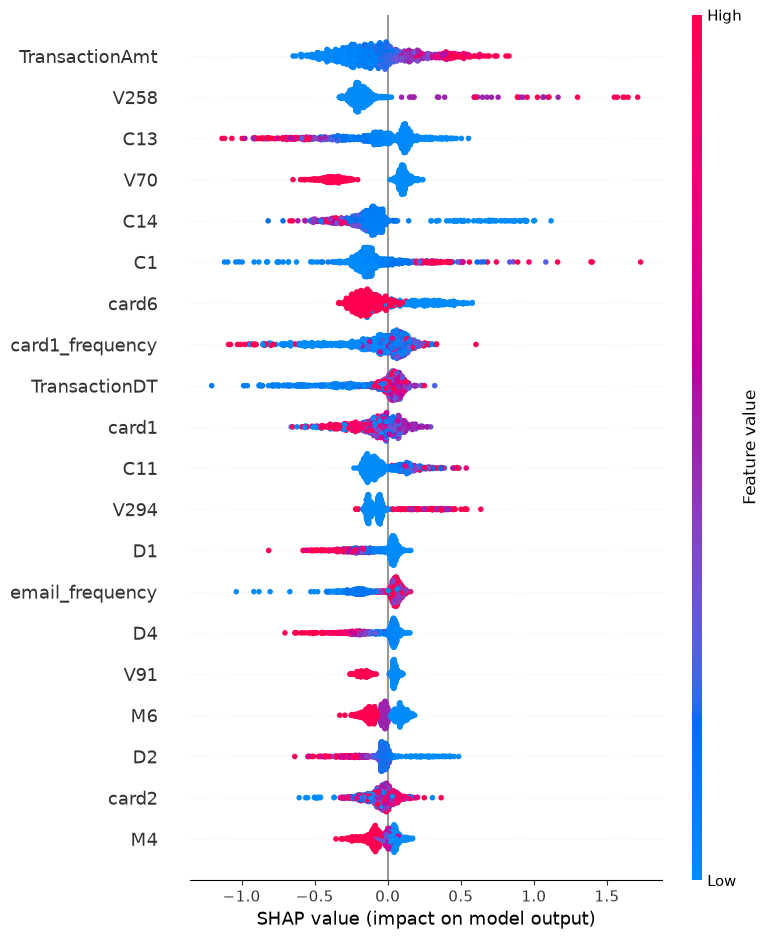

In [21]:
shap.summary_plot(
    shap_values,
    sample_data
)

In [22]:
import shap

print(shap.__version__)

0.51.0


In [23]:
explainer = shap.TreeExplainer(xgb_weighted)

In [24]:
sample_data = X.sample(
    1000,
    random_state=42
)

print(sample_data.shape)

(1000, 430)


In [25]:
# calculate SHAP values
shap_values = explainer.shap_values(sample_data)

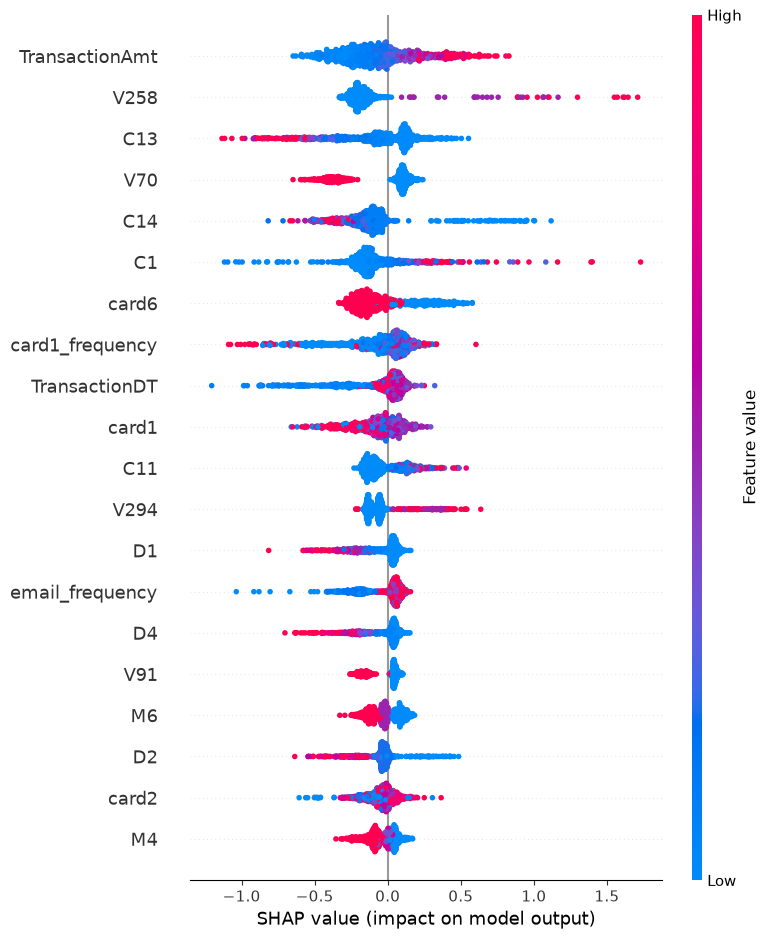

In [26]:
shap.summary_plot(
    shap_values,
    sample_data
)

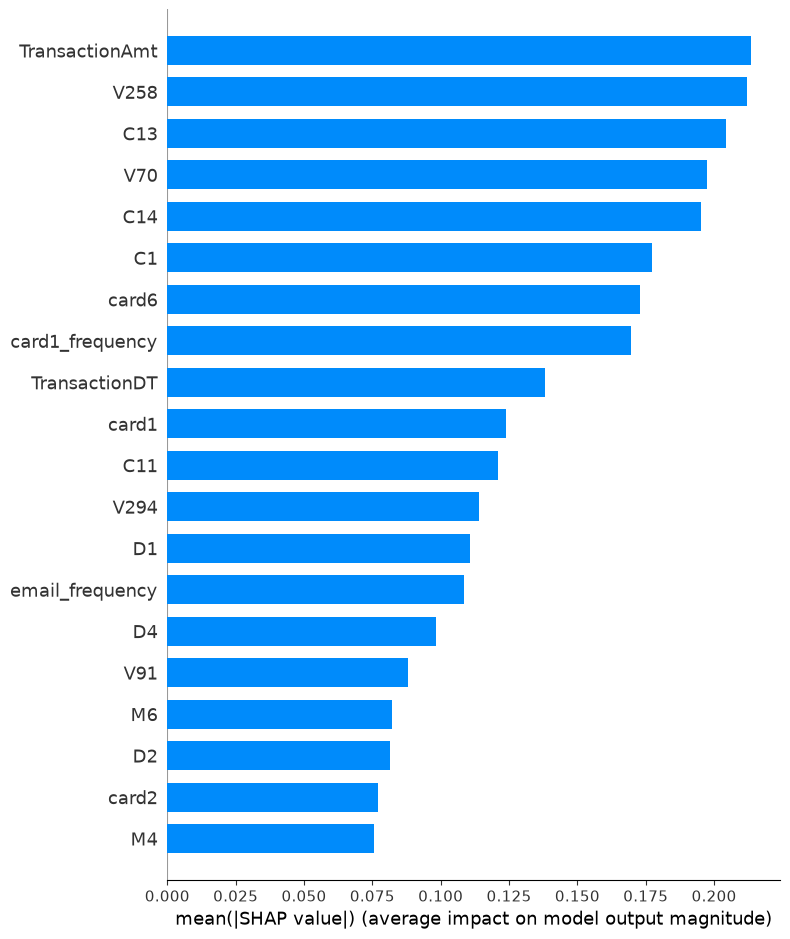

In [27]:
shap.summary_plot(
    shap_values,
    sample_data,
    plot_type="bar"
)

## SHAP Explainability Findings

SHAP analysis was used to explain model predictions and identify key fraud drivers.

Top features influencing fraud predictions:

- TransactionAmt
- V258
- C13
- V70
- C14
- card1_frequency
- TransactionDT
- email_frequency

The analysis confirmed that both original transactional features and engineered behavioral features significantly contributed to fraud detection performance.

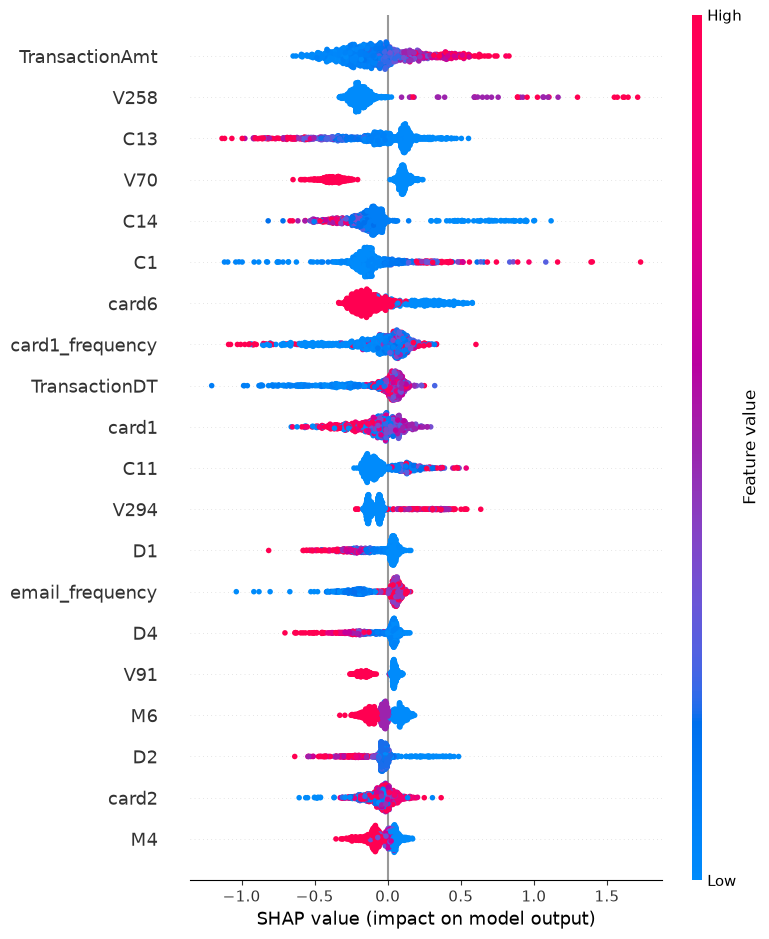

In [28]:
shap.summary_plot(
    shap_values,
    sample_data,
    show=False
)

In [29]:
import matplotlib.pyplot as plt

plt.savefig(
    "../outputs/shap_summary.png",
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [30]:
import joblib
import xgboost as xgb
import matplotlib.pyplot as plt

xgb_weighted = joblib.load("../models/xgb_weighted_model.pkl")

<Figure size 1200x800 with 0 Axes>

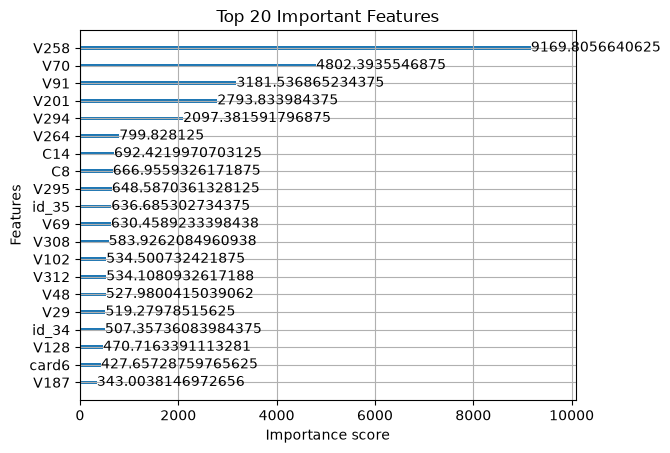

In [31]:
plt.figure(figsize=(12,8))

xgb.plot_importance(
    xgb_weighted,
    max_num_features=20,
    importance_type="gain"
)

plt.title("Top 20 Important Features")

plt.savefig(
    "../outputs/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()